In [1]:
"""Payments data warehouse: REST API ingestion -> ETL -> star schema -> data quality -> KPI monitoring -> experiment -> ML.

Runs fully on a laptop: SQLite (standard library) plays the role of the warehouse, so every SQL statement is
plain ANSI-style SQL that ports to MySQL / Oracle with minor syntax changes.

What it demonstrates (mapped to a data-scientist job in a bank's analytics team):
  * REST API capture       - live USD/GHS exchange rate from a public API, with a labelled offline fallback
  * ETL + star schema      - staging tables -> dim_* and fact_transactions, surrogate keys, indexes
  * Data profiling + tests - profiling table, threshold-based quality checks, reject table, reconciliation
  * Ticketing              - failed quality checks open tickets (SysAid-style) in a dq_tickets table
  * Metric definitions     - KPI views (success rate, GMV, fee revenue, ...) defined once in SQL
  * Monitoring             - rolling z-score alerts on failure rate by channel
  * Big-data pattern       - MapReduce-style map/combine/reduce in pure Python, checked against SQL GROUP BY
  * Experiment analysis    - randomized test with a customer-level (cluster) bootstrap
  * Predictive model       - failed-transaction model trained on features pulled from the warehouse
  * Excel / PowerPivot     - workbook export of dimensions and aggregated facts

DATA: SIMULATED payments (June-September 2026) with data-quality problems injected on purpose, an incident
window, and a built-in experiment effect. Nothing here is real bank data.

Run: python payments_dw.py    (QUICK=1 python payments_dw.py for a fast run)
Needs: pip install numpy pandas scipy scikit-learn matplotlib requests openpyxl
"""

"Payments data warehouse: REST API ingestion -> ETL -> star schema -> data quality -> KPI monitoring -> experiment -> ML.\n\nRuns fully on a laptop: SQLite (standard library) plays the role of the warehouse, so every SQL statement is\nplain ANSI-style SQL that ports to MySQL / Oracle with minor syntax changes.\n\nWhat it demonstrates (mapped to a data-scientist job in a bank's analytics team):\n  * REST API capture       - live USD/GHS exchange rate from a public API, with a labelled offline fallback\n  * ETL + star schema      - staging tables -> dim_* and fact_transactions, surrogate keys, indexes\n  * Data profiling + tests - profiling table, threshold-based quality checks, reject table, reconciliation\n  * Ticketing              - failed quality checks open tickets (SysAid-style) in a dq_tickets table\n  * Metric definitions     - KPI views (success rate, GMV, fee revenue, ...) defined once in SQL\n  * Monitoring             - rolling z-score alerts on failure rate by channel\n  * 

In [2]:
import os
import sqlite3
import time
from collections import defaultdict
from functools import reduce
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

SEED = 42
QUICK = os.getenv("QUICK", "0") == "1"
DB_PATH = "payments_dw.db"
EXCEL_PATH = "payments_dw_powerpivot.xlsx"

START, END, AS_OF = "2026-06-01", "2026-09-27", "2026-09-28"
LAUNCH_DATE = "2026-09-01"                       # experiment launch: new mobile-money retry flow
INCIDENT = ("2026-08-14", "2026-08-16")          # simulated mobile-money outage window
N_CUSTOMERS, N_MERCHANTS, TXN_PER_DAY = (1_000, 60, 300) if QUICK else (5_000, 300, 1_500)

FX_URL = "https://open.er-api.com/v6/latest/USD"  # free endpoint, no API key
FALLBACK_USD_GHS = 11.0                           # placeholder used ONLY if the API is unreachable

Path(DB_PATH).unlink(missing_ok=True)
con = sqlite3.connect(DB_PATH)
rng = np.random.default_rng(SEED)


def sql(query: str, params=()):
    return pd.read_sql_query(query, con, params=params)

In [3]:
def fetch_usd_ghs():
    try:
        r = requests.get(FX_URL, timeout=10)
        r.raise_for_status()
        data = r.json()
        return float(data["rates"]["GHS"]), "api:open.er-api.com", data.get("time_last_update_utc")
    except Exception as exc:
        print(f"FX API unavailable ({type(exc).__name__}); using placeholder rate {FALLBACK_USD_GHS}.")
        return FALLBACK_USD_GHS, "fallback", None


usd_ghs, fx_source, fx_time = fetch_usd_ghs()
pd.DataFrame([{"base": "USD", "quote": "GHS", "rate": usd_ghs, "source": fx_source, "fetched_at": fx_time or "n/a"}]
             ).to_sql("fx_rates", con, index=False)
print(f"USD/GHS = {usd_ghs} (source: {fx_source})")

USD/GHS = 11.635545 (source: api:open.er-api.com)


In [4]:
def simulate_source():
    customers = pd.DataFrame({
        "customer_id": np.arange(1, N_CUSTOMERS + 1),
        "segment": rng.choice(["retail", "premium", "sme"], N_CUSTOMERS, p=[0.75, 0.10, 0.15]),
        "region": rng.choice(["Greater Accra", "Ashanti", "Western", "Northern", "Eastern"], N_CUSTOMERS,
                             p=[0.35, 0.25, 0.15, 0.12, 0.13]),
        "age_band": rng.choice(["18-24", "25-34", "35-44", "45-54", "55+"], N_CUSTOMERS, p=[0.15, 0.35, 0.25, 0.15, 0.10]),
        "signup_date": (pd.Timestamp("2020-01-01") + pd.to_timedelta(rng.integers(0, 2300, N_CUSTOMERS), unit="D")
                        ).strftime("%Y-%m-%d"),
    })
    merchants = pd.DataFrame({
        "merchant_id": np.arange(1, N_MERCHANTS + 1),
        "category": rng.choice(["groceries", "telecom", "utilities", "fuel", "restaurants", "e-commerce"], N_MERCHANTS,
                               p=[0.25, 0.15, 0.15, 0.15, 0.15, 0.15]),
        "region": rng.choice(["Greater Accra", "Ashanti", "Western", "Northern", "Eastern"], N_MERCHANTS),
    })
    arm = pd.DataFrame({"customer_id": customers["customer_id"],
                        "arm": rng.choice(["control", "treatment"], N_CUSTOMERS)})

    days = pd.date_range(START, END)
    mult = np.where(days.dayofweek >= 5, 0.85, 1.0) * np.where((days.day >= 25) & (days.day <= 28), 1.2, 1.0)
    counts = np.round(TXN_PER_DAY * mult).astype(int)
    day_idx = np.repeat(np.arange(len(days)), counts)
    n = len(day_idx)
    hour_w = np.array([1, 1, 1, 1, 1, 2, 4, 7, 9, 9, 8, 8, 9, 8, 8, 8, 9, 10, 9, 7, 5, 3, 2, 1], dtype=float)
    hour = rng.choice(24, n, p=hour_w / hour_w.sum())
    ts = days[day_idx] + pd.to_timedelta(hour, unit="h") + pd.to_timedelta(rng.integers(0, 3600, n), unit="s")

    w = rng.lognormal(0, 0.8, N_CUSTOMERS)                        # heavy and light users
    cust = rng.choice(customers["customer_id"], n, p=w / w.sum())
    merch = rng.integers(1, N_MERCHANTS + 1, n)
    channel = rng.choice(["mobile_money", "card", "bank_transfer", "ussd"], n, p=[0.45, 0.25, 0.10, 0.20])
    category = merchants.set_index("merchant_id").loc[merch, "category"].to_numpy()
    currency = np.where((channel == "card") & (category == "e-commerce"), "USD", "GHS")
    mu = pd.Series(channel).map({"mobile_money": 3.5, "card": 4.3, "bank_transfer": 5.5, "ussd": 3.0}).to_numpy()
    amount = np.round(np.where(currency == "USD", rng.lognormal(3.4, 0.8, n), rng.lognormal(mu, 1.0)), 2)

    p_fail = pd.Series(channel).map({"mobile_money": 0.05, "card": 0.03, "bank_transfer": 0.02, "ussd": 0.08}).to_numpy()
    p_fail = p_fail + np.where(hour <= 4, 0.03, 0.0) + np.where(amount > 1000, 0.02, 0.0)
    date_str = days[day_idx].strftime("%Y-%m-%d")
    incident = (date_str >= INCIDENT[0]) & (date_str <= INCIDENT[1]) & (channel == "mobile_money")
    p_fail = p_fail + np.where(incident, 0.20, 0.0)
    treated = arm.set_index("customer_id").loc[cust, "arm"].to_numpy() == "treatment"
    p_fail = p_fail - np.where(treated & (channel == "mobile_money") & (date_str >= LAUNCH_DATE), 0.015, 0.0)
    u = rng.random(n)
    status = np.where(u < p_fail, "failed", np.where(u < p_fail + 0.01, "reversed", "success"))
    fee_rate = pd.Series(channel).map({"mobile_money": 0.008, "card": 0.015, "bank_transfer": 0.002, "ussd": 0.005}).to_numpy()
    fee = np.where(status == "success", np.round(amount * fee_rate, 2), 0.0)

    tx = pd.DataFrame({"txn_id": [f"T{i:08d}" for i in range(n)], "txn_ts": ts.strftime("%Y-%m-%d %H:%M:%S"),
                       "customer_id": pd.array(cust, dtype="Int64"), "merchant_id": merch, "channel": channel,
                       "amount": amount, "currency": currency, "status": status, "fee": fee})

    # inject data-quality problems (as if from a messy source system)
    pick = lambda p: rng.random(n) < p
    tx.loc[pick(0.003), "customer_id"] = pd.NA
    m = pick(0.001); tx.loc[m, "amount"] = -tx.loc[m, "amount"]
    tx.loc[pick(0.002), "merchant_id"] = 99_999
    tx.loc[pick(0.001), "txn_ts"] = "2026-12-01 10:00:00"
    tx.loc[pick(0.001), "currency"] = "GHC"
    tx = pd.concat([tx, tx.sample(frac=0.005, random_state=1)], ignore_index=True)     # duplicate rows
    return customers, merchants, arm, tx


customers, merchants, arm, tx = simulate_source()
customers.to_sql("stg_customers", con, index=False)
merchants.to_sql("stg_merchants", con, index=False)
arm.to_sql("experiment_assignment", con, index=False)
tx.to_sql("stg_transactions", con, index=False, chunksize=50_000)
print({"customers": len(customers), "merchants": len(merchants), "raw transactions": len(tx)})

{'customers': 5000, 'merchants': 300, 'raw transactions': 175955}


In [5]:
def profile(table):
    df = sql(f"SELECT * FROM {table}")
    return pd.DataFrame({"dtype": df.dtypes.astype(str), "nulls": df.isna().sum(),
                         "null_pct": (df.isna().mean() * 100).round(2), "distinct": df.nunique(),
                         "min": df.min(numeric_only=True), "max": df.max(numeric_only=True)})


print(profile("stg_transactions").to_string())

               dtype  nulls  null_pct  distinct      min       max
amount       float64      0      0.00     34564 -1319.13  10065.66
channel       object      0      0.00         4      NaN       NaN
currency      object      0      0.00         3      NaN       NaN
customer_id  float64    512      0.29      4998     1.00   5000.00
fee          float64      0      0.00      1402     0.00     57.58
merchant_id    int64      0      0.00       301     1.00  99999.00
status        object      0      0.00         3      NaN       NaN
txn_id        object      0      0.00    175080      NaN       NaN
txn_ts        object      0      0.00    172842      NaN       NaN


In [6]:
DQ_CHECKS = [   # (name, severity, max allowed share of rows, SQL returning number of failing rows)
    ("duplicate_txn_id", "critical", 0.001, "SELECT COUNT(*) - COUNT(DISTINCT txn_id) FROM stg_transactions"),
    ("null_customer_id", "high", 0.001, "SELECT COUNT(*) FROM stg_transactions WHERE customer_id IS NULL"),
    ("non_positive_amount", "high", 0.0005, "SELECT COUNT(*) FROM stg_transactions WHERE amount <= 0"),
    ("orphan_merchant_id", "high", 0.001,
     "SELECT COUNT(*) FROM stg_transactions WHERE merchant_id NOT IN (SELECT merchant_id FROM stg_merchants)"),
    ("future_timestamp", "medium", 0.002, f"SELECT COUNT(*) FROM stg_transactions WHERE txn_ts > '{AS_OF}'"),
    ("invalid_currency", "medium", 0.002, "SELECT COUNT(*) FROM stg_transactions WHERE currency NOT IN ('GHS','USD')"),
    ("invalid_status", "medium", 0.0,
     "SELECT COUNT(*) FROM stg_transactions WHERE status NOT IN ('success','failed','reversed')"),
]
PRIORITY = {"critical": "P1", "high": "P2", "medium": "P3"}
run_at = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
total_rows = con.execute("SELECT COUNT(*) FROM stg_transactions").fetchone()[0]

con.execute("""CREATE TABLE dq_results (check_name TEXT, severity TEXT, failing_rows INTEGER, total_rows INTEGER,
               fail_pct REAL, threshold_pct REAL, status TEXT, run_at TEXT)""")
con.execute("""CREATE TABLE dq_tickets (ticket_id INTEGER PRIMARY KEY AUTOINCREMENT, opened_at TEXT, check_name TEXT,
               priority TEXT, summary TEXT, status TEXT)""")
for name, severity, threshold, query in DQ_CHECKS:
    failing = con.execute(query).fetchone()[0]
    pct = failing / total_rows
    status = "PASS" if pct <= threshold else "FAIL"
    con.execute("INSERT INTO dq_results VALUES (?,?,?,?,?,?,?,?)",
                (name, severity, failing, total_rows, pct * 100, threshold * 100, status, run_at))
    if status == "FAIL":
        con.execute("INSERT INTO dq_tickets (opened_at, check_name, priority, summary, status) VALUES (?,?,?,?,?)",
                    (run_at, name, PRIORITY[severity],
                     f"{name}: {failing:,} rows ({pct:.2%}) exceed the {threshold:.2%} threshold", "OPEN"))
con.commit()
print(sql("SELECT check_name, severity, failing_rows, ROUND(fail_pct, 3) AS fail_pct, threshold_pct, status FROM dq_results").to_string(index=False))
print("\nOpen tickets:")
print(sql("SELECT ticket_id, priority, summary, status FROM dq_tickets").to_string(index=False))

         check_name severity  failing_rows  fail_pct  threshold_pct status
   duplicate_txn_id critical           875     0.497           0.10   FAIL
   null_customer_id     high           512     0.291           0.10   FAIL
non_positive_amount     high           186     0.106           0.05   FAIL
 orphan_merchant_id     high           350     0.199           0.10   FAIL
   future_timestamp   medium           169     0.096           0.20   PASS
   invalid_currency   medium           191     0.109           0.20   PASS
     invalid_status   medium             0     0.000           0.00   PASS

Open tickets:
 ticket_id priority                                                          summary status
         1       P1    duplicate_txn_id: 875 rows (0.50%) exceed the 0.10% threshold   OPEN
         2       P2    null_customer_id: 512 rows (0.29%) exceed the 0.10% threshold   OPEN
         3       P2 non_positive_amount: 186 rows (0.11%) exceed the 0.05% threshold   OPEN
         4       

In [7]:
con.executescript("""
CREATE TABLE dim_customer (customer_key INTEGER PRIMARY KEY AUTOINCREMENT, customer_id INTEGER UNIQUE,
                           segment TEXT, region TEXT, age_band TEXT, signup_date TEXT);
CREATE TABLE dim_merchant (merchant_key INTEGER PRIMARY KEY AUTOINCREMENT, merchant_id INTEGER UNIQUE,
                           category TEXT, region TEXT);
CREATE TABLE dim_channel  (channel_key INTEGER PRIMARY KEY AUTOINCREMENT, channel_name TEXT UNIQUE);
CREATE TABLE dim_status   (status_key INTEGER PRIMARY KEY AUTOINCREMENT, status_name TEXT UNIQUE);
CREATE TABLE dim_date     (date_key INTEGER PRIMARY KEY, date TEXT, year INTEGER, month INTEGER, day INTEGER,
                           dow INTEGER, is_weekend INTEGER, is_payday INTEGER, is_month_end INTEGER);
CREATE TABLE fact_transactions (
    txn_key INTEGER PRIMARY KEY AUTOINCREMENT, txn_id TEXT UNIQUE, date_key INTEGER, hour INTEGER,
    customer_key INTEGER, merchant_key INTEGER, channel_key INTEGER, status_key INTEGER,
    amount_local REAL, currency TEXT, amount_ghs REAL, fee_ghs REAL, is_failed INTEGER, is_reversed INTEGER,
    FOREIGN KEY (date_key) REFERENCES dim_date(date_key), FOREIGN KEY (customer_key) REFERENCES dim_customer(customer_key),
    FOREIGN KEY (merchant_key) REFERENCES dim_merchant(merchant_key), FOREIGN KEY (channel_key) REFERENCES dim_channel(channel_key),
    FOREIGN KEY (status_key) REFERENCES dim_status(status_key));

INSERT INTO dim_customer (customer_id, segment, region, age_band, signup_date)
    SELECT customer_id, segment, region, age_band, signup_date FROM stg_customers ORDER BY customer_id;
INSERT INTO dim_merchant (merchant_id, category, region)
    SELECT merchant_id, category, region FROM stg_merchants ORDER BY merchant_id;
INSERT INTO dim_channel (channel_name) VALUES ('mobile_money'), ('card'), ('bank_transfer'), ('ussd');
INSERT INTO dim_status (status_name) VALUES ('success'), ('failed'), ('reversed');
""")
dates = pd.date_range(START, END)
pd.DataFrame({"date_key": dates.strftime("%Y%m%d").astype(int), "date": dates.strftime("%Y-%m-%d"), "year": dates.year,
              "month": dates.month, "day": dates.day, "dow": dates.dayofweek, "is_weekend": (dates.dayofweek >= 5).astype(int),
              "is_payday": ((dates.day >= 25) & (dates.day <= 28)).astype(int),
              "is_month_end": dates.is_month_end.astype(int)}).to_sql("dim_date", con, if_exists="append", index=False)

# one pass flags every staging row with a single reject reason (NULL = valid); duplicates keep their first copy
con.executescript(f"""
CREATE TABLE stg_flagged AS
SELECT * FROM (
    SELECT r.*, CASE WHEN rn > 1 THEN 'duplicate_txn_id'
                     WHEN customer_id IS NULL THEN 'null_customer_id'
                     WHEN amount <= 0 THEN 'non_positive_amount'
                     WHEN merchant_id NOT IN (SELECT merchant_id FROM stg_merchants) THEN 'orphan_merchant_id'
                     WHEN txn_ts > '{AS_OF}' THEN 'future_timestamp'
                     WHEN currency NOT IN ('GHS','USD') THEN 'invalid_currency'
                     WHEN status NOT IN ('success','failed','reversed') THEN 'invalid_status' END AS reject_reason
    FROM (SELECT s.*, ROW_NUMBER() OVER (PARTITION BY txn_id ORDER BY txn_ts, rowid) AS rn FROM stg_transactions s) r);

CREATE TABLE dq_rejects AS SELECT * FROM stg_flagged WHERE reject_reason IS NOT NULL;

INSERT INTO fact_transactions (txn_id, date_key, hour, customer_key, merchant_key, channel_key, status_key,
                               amount_local, currency, amount_ghs, fee_ghs, is_failed, is_reversed)
SELECT t.txn_id, CAST(REPLACE(SUBSTR(t.txn_ts, 1, 10), '-', '') AS INTEGER), CAST(SUBSTR(t.txn_ts, 12, 2) AS INTEGER),
       c.customer_key, m.merchant_key, ch.channel_key, st.status_key, t.amount, t.currency,
       CASE WHEN t.currency = 'USD' THEN ROUND(t.amount * {usd_ghs}, 2) ELSE t.amount END,
       CASE WHEN t.currency = 'USD' THEN ROUND(t.fee * {usd_ghs}, 2) ELSE t.fee END,
       CASE WHEN t.status = 'failed' THEN 1 ELSE 0 END, CASE WHEN t.status = 'reversed' THEN 1 ELSE 0 END
FROM stg_flagged t
JOIN dim_customer c ON c.customer_id = t.customer_id
JOIN dim_merchant m ON m.merchant_id = t.merchant_id
JOIN dim_channel ch ON ch.channel_name = t.channel
JOIN dim_status st ON st.status_name = t.status
WHERE t.reject_reason IS NULL;

CREATE INDEX ix_fact_date ON fact_transactions(date_key);
CREATE INDEX ix_fact_customer ON fact_transactions(customer_key);
CREATE INDEX ix_fact_merchant ON fact_transactions(merchant_key);
CREATE INDEX ix_fact_channel ON fact_transactions(channel_key);
""")
con.commit()

n_stg = con.execute("SELECT COUNT(*) FROM stg_transactions").fetchone()[0]
n_fact = con.execute("SELECT COUNT(*) FROM fact_transactions").fetchone()[0]
n_rej = con.execute("SELECT COUNT(*) FROM dq_rejects").fetchone()[0]
print(f"Reconciliation: staging {n_stg:,} = fact {n_fact:,} + rejected {n_rej:,}  ->  {'OK' if n_stg == n_fact + n_rej else 'MISMATCH'}")
assert n_stg == n_fact + n_rej, "row counts do not reconcile"
print(sql("SELECT reject_reason, COUNT(*) AS rows FROM dq_rejects GROUP BY 1 ORDER BY 2 DESC").to_string(index=False))

Reconciliation: staging 175,955 = fact 173,682 + rejected 2,273  ->  OK
      reject_reason  rows
   duplicate_txn_id   875
   null_customer_id   508
 orphan_merchant_id   349
   invalid_currency   188
non_positive_amount   186
   future_timestamp   167


In [8]:
con.executescript("""
DROP VIEW IF EXISTS vw_kpi_daily;
CREATE VIEW vw_kpi_daily AS
SELECT d.date, COUNT(*) AS txn_count,
       ROUND(1.0 * SUM(CASE WHEN f.is_failed = 0 AND f.is_reversed = 0 THEN 1 ELSE 0 END) / COUNT(*), 4) AS success_rate,
       ROUND(1.0 * SUM(f.is_failed) / COUNT(*), 4) AS failure_rate,
       ROUND(SUM(CASE WHEN f.is_failed = 0 AND f.is_reversed = 0 THEN f.amount_ghs ELSE 0 END), 2) AS gmv_ghs,
       ROUND(SUM(f.fee_ghs), 2) AS fee_revenue_ghs,
       ROUND(SUM(CASE WHEN f.is_failed = 0 AND f.is_reversed = 0 THEN f.amount_ghs ELSE 0 END) /
             NULLIF(SUM(CASE WHEN f.is_failed = 0 AND f.is_reversed = 0 THEN 1 ELSE 0 END), 0), 2) AS avg_ticket_ghs,
       COUNT(DISTINCT f.customer_key) AS active_customers
FROM fact_transactions f JOIN dim_date d ON d.date_key = f.date_key GROUP BY d.date;

DROP VIEW IF EXISTS vw_kpi_daily_channel;
CREATE VIEW vw_kpi_daily_channel AS
SELECT d.date, ch.channel_name AS channel, COUNT(*) AS txn_count, SUM(f.is_failed) AS failed,
       ROUND(1.0 * SUM(f.is_failed) / COUNT(*), 4) AS failure_rate
FROM fact_transactions f JOIN dim_date d ON d.date_key = f.date_key JOIN dim_channel ch ON ch.channel_key = f.channel_key
GROUP BY d.date, ch.channel_name;
""")
KPI_DEFINITIONS = {
    "txn_count": "All valid transactions in the day",
    "success_rate": "Share of transactions with status 'success'",
    "failure_rate": "Share of transactions with status 'failed'",
    "gmv_ghs": "Sum of amount (converted to GHS) over successful transactions",
    "fee_revenue_ghs": "Sum of fees (GHS) charged on successful transactions",
    "avg_ticket_ghs": "GMV divided by the number of successful transactions",
    "active_customers": "Distinct customers with at least one transaction",
}
print(pd.Series(KPI_DEFINITIONS, name="definition").to_string())
kpi_daily = sql("SELECT * FROM vw_kpi_daily ORDER BY date")
print(kpi_daily.tail(7).to_string(index=False))

weekly = kpi_daily.assign(week=pd.to_datetime(kpi_daily["date"]).dt.to_period("W").astype(str)).groupby("week").agg(
    txns=("txn_count", "sum"), gmv_ghs=("gmv_ghs", "sum"), fee_revenue_ghs=("fee_revenue_ghs", "sum"))
print("\nWeekly summary:")
print(weekly.round(0).tail(6).to_string())

txn_count                           All valid transactions in the day
success_rate              Share of transactions with status 'success'
failure_rate               Share of transactions with status 'failed'
gmv_ghs             Sum of amount (converted to GHS) over successf...
fee_revenue_ghs     Sum of fees (GHS) charged on successful transa...
avg_ticket_ghs      GMV divided by the number of successful transa...
active_customers     Distinct customers with at least one transaction
      date  txn_count  success_rate  failure_rate   gmv_ghs  fee_revenue_ghs  avg_ticket_ghs  active_customers
2026-09-21       1488        0.9402        0.0470 158428.08          1277.04          113.24              1169
2026-09-22       1486        0.9415        0.0444 176408.42          1571.25          126.10              1195
2026-09-23       1485        0.9441        0.0438 181453.10          1615.44          129.42              1177
2026-09-24       1492        0.9504        0.0422 162649.38       

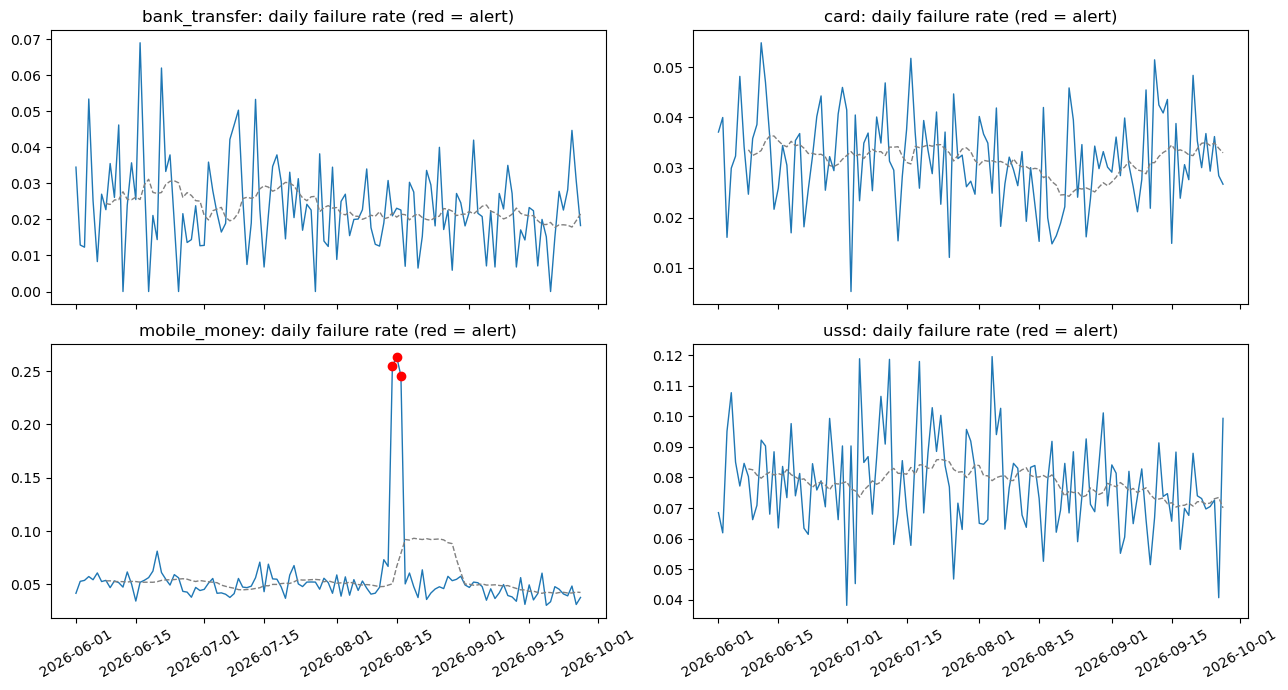

      date      channel  failure_rate  baseline  z_score
2026-08-14 mobile_money         0.254     0.051   24.256
2026-08-15 mobile_money         0.264     0.067   18.530
2026-08-16 mobile_money         0.246     0.079   14.560


In [9]:
MIN_TXNS, MIN_JUMP, Z_LIMIT = 50, 0.02, 4.0       # volume guard, materiality guard, significance
by_ch = sql("SELECT * FROM vw_kpi_daily_channel ORDER BY date")
alerts = []
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, (channel, g) in zip(axes.ravel(), by_ch.groupby("channel")):
    g = g.set_index(pd.to_datetime(g["date"]))
    base_p = g["failed"].shift(1).rolling(14, min_periods=7).sum() / g["txn_count"].shift(1).rolling(14, min_periods=7).sum()
    z = (g["failure_rate"] - base_p) / np.sqrt(base_p * (1 - base_p) / g["txn_count"])
    hit = (z > Z_LIMIT) & (g["txn_count"] >= MIN_TXNS) & ((g["failure_rate"] - base_p) > MIN_JUMP)
    for day in g.index[hit]:
        alerts.append({"date": day.strftime("%Y-%m-%d"), "channel": channel, "failure_rate": float(g.loc[day, "failure_rate"]),
                       "baseline": float(base_p[day]), "z_score": float(z[day])})
    ax.plot(g.index, g["failure_rate"], lw=1)
    ax.plot(base_p.index, base_p.values, "--", lw=1, color="grey")
    ax.scatter(g.index[hit], g.loc[hit, "failure_rate"], color="red", zorder=3)
    ax.set_title(f"{channel}: daily failure rate (red = alert)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
kpi_alerts = pd.DataFrame(alerts, columns=["date", "channel", "failure_rate", "baseline", "z_score"])
kpi_alerts.to_sql("kpi_alerts", con, if_exists="replace", index=False)
print(kpi_alerts.round(3).to_string(index=False) if len(kpi_alerts) else "no alerts")

In [10]:
def mapper(row):
    merchant_key, amount_ghs, is_failed, is_reversed = row
    ok = not is_failed and not is_reversed
    yield merchant_key, (1, amount_ghs if ok else 0.0)


def combiner(chunk_rows):                     # local aggregation per chunk, as a Hadoop combiner would do
    partial = defaultdict(lambda: (0, 0.0))
    for row in chunk_rows:
        for key, (c, a) in mapper(row):
            pc, pa = partial[key]
            partial[key] = (pc + c, pa + a)
    return partial


def reducer(acc, partial):                    # merge partial results from every chunk
    for key, (c, a) in partial.items():
        ac, aa = acc.get(key, (0, 0.0))
        acc[key] = (ac + c, aa + a)
    return acc


t0 = time.perf_counter()
cur = con.execute("SELECT merchant_key, amount_ghs, is_failed, is_reversed FROM fact_transactions")
partials = []
while chunk := cur.fetchmany(50_000):
    partials.append(combiner(chunk))
mr = reduce(reducer, partials, {})
t_mr = time.perf_counter() - t0

t0 = time.perf_counter()
sql_result = sql("""SELECT merchant_key, COUNT(*) AS txns,
                    SUM(CASE WHEN is_failed = 0 AND is_reversed = 0 THEN amount_ghs ELSE 0 END) AS gmv
                    FROM fact_transactions GROUP BY merchant_key""").set_index("merchant_key")
t_sql = time.perf_counter() - t0
mr_df = pd.DataFrame.from_dict(mr, orient="index", columns=["txns", "gmv"]).sort_index()
assert (mr_df["txns"].values == sql_result.sort_index()["txns"].values).all()
assert np.allclose(mr_df["gmv"].values, sql_result.sort_index()["gmv"].values)
print(f"MapReduce-style result matches SQL GROUP BY for {len(mr_df)} merchants "
      f"(python {t_mr:.2f}s vs sql {t_sql:.2f}s)")
print(mr_df.sort_values("gmv", ascending=False).head(5).round(1).to_string())

MapReduce-style result matches SQL GROUP BY for 300 merchants (python 0.32s vs sql 0.85s)
     txns       gmv
144   586  124130.6
263   659  123049.1
129   553  121354.6
253   622  121063.2
98    620  120060.1


In [11]:
exp = sql(f"""
SELECT e.customer_id, e.arm, COUNT(*) AS n_txn, SUM(f.is_failed) AS n_failed
FROM fact_transactions f
JOIN dim_customer c ON c.customer_key = f.customer_key
JOIN experiment_assignment e ON e.customer_id = c.customer_id
JOIN dim_channel ch ON ch.channel_key = f.channel_key
JOIN dim_date d ON d.date_key = f.date_key
WHERE ch.channel_name = 'mobile_money' AND d.date >= '{LAUNCH_DATE}'
GROUP BY e.customer_id, e.arm""")
grp = exp.groupby("arm")[["n_txn", "n_failed"]].sum()
n_c, n_t = (exp["arm"] == "control").sum(), (exp["arm"] == "treatment").sum()
srm_p = stats.chisquare([n_c, n_t]).pvalue
rate_c, rate_t = grp.loc["control", "n_failed"] / grp.loc["control", "n_txn"], grp.loc["treatment", "n_failed"] / grp.loc["treatment", "n_txn"]

# naive transaction-level z-test (treats every transaction as independent)
p_pool = (grp["n_failed"].sum()) / grp["n_txn"].sum()
se = np.sqrt(p_pool * (1 - p_pool) * (1 / grp.loc["control", "n_txn"] + 1 / grp.loc["treatment", "n_txn"]))
z_naive = (rate_t - rate_c) / se
p_naive = 2 * stats.norm.sf(abs(z_naive))

# customer-level bootstrap: resample customers (the randomization unit), keep all their transactions
bs_rng = np.random.default_rng(0)
arrays = {a: (g["n_txn"].to_numpy(), g["n_failed"].to_numpy()) for a, g in exp.groupby("arm")}
B = 500 if QUICK else 2_000
diffs = np.empty(B)
for b in range(B):
    r = {}
    for a, (nt, nf) in arrays.items():
        idx = bs_rng.integers(0, len(nt), len(nt))
        r[a] = nf[idx].sum() / nt[idx].sum()
    diffs[b] = r["treatment"] - r["control"]
lo, hi = np.percentile(diffs, [2.5, 97.5])

print(f"Customers: control {n_c:,}, treatment {n_t:,} (sample-ratio check p={srm_p:.3f}: "
      f"{'no evidence of assignment problems' if srm_p > 0.001 else 'INVESTIGATE assignment'})")
print(f"Mobile-money failure rate: control {rate_c:.2%}, treatment {rate_t:.2%}, difference {rate_t - rate_c:+.2%}")
print(f"Naive transaction-level z-test: p={p_naive:.4f}")
print(f"Customer-level bootstrap 95% CI for the difference: [{lo:+.2%}, {hi:+.2%}] "
      f"({'excludes' if lo > 0 or hi < 0 else 'includes'} zero)")

Customers: control 2,134, treatment 2,161 (sample-ratio check p=0.680: no evidence of assignment problems)
Mobile-money failure rate: control 4.97%, treatment 3.58%, difference -1.39%
Naive transaction-level z-test: p=0.0000
Customer-level bootstrap 95% CI for the difference: [-1.97%, -0.78%] (excludes zero)


In [12]:
feat = sql("""
SELECT f.is_failed AS target, ch.channel_name AS channel, mc.category, c.segment, c.region,
       f.hour, d.dow, d.is_weekend, d.is_payday, f.amount_ghs, d.date
FROM fact_transactions f
JOIN dim_date d ON d.date_key = f.date_key
JOIN dim_channel ch ON ch.channel_key = f.channel_key
JOIN dim_merchant mc ON mc.merchant_key = f.merchant_key
JOIN dim_customer c ON c.customer_key = f.customer_key""")
CAT = ["channel", "category", "segment", "region"]
NUM = ["hour", "dow", "is_weekend", "is_payday", "amount_ghs"]
train, test = feat[feat["date"] < LAUNCH_DATE], feat[feat["date"] >= LAUNCH_DATE]
model = Pipeline([
    ("enc", ColumnTransformer([("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), CAT)],
                              remainder="passthrough")),
    ("hgb", HistGradientBoostingClassifier(categorical_features=list(range(len(CAT))), max_depth=4, learning_rate=0.05,
                                           max_iter=200, random_state=SEED)),
]).fit(train[CAT + NUM], train["target"])
prob = model.predict_proba(test[CAT + NUM])[:, 1]
top = np.argsort(-prob)[: len(prob) // 10]
print(f"Train {len(train):,} rows (before {LAUNCH_DATE}), test {len(test):,} rows | base failure rate {test['target'].mean():.2%}")
print(f"Test AUC {roc_auc_score(test['target'], prob):.3f} | avg precision {average_precision_score(test['target'], prob):.3f} "
      f"| top-decile lift {test['target'].iloc[top].mean() / test['target'].mean():.2f}x")

sample = test.sample(min(20_000, len(test)), random_state=SEED)
imp = permutation_importance(model, sample[CAT + NUM], sample["target"], scoring="roc_auc", n_repeats=3, random_state=SEED)
print(pd.Series(imp.importances_mean, index=CAT + NUM).sort_values(ascending=False).round(4).to_string())

Train 134,505 rows (before 2026-09-01), test 39,177 rows | base failure rate 4.39%
Test AUC 0.591 | avg precision 0.060 | top-decile lift 1.53x
channel       0.0904
hour          0.0039
region        0.0021
is_payday     0.0019
segment       0.0001
is_weekend    0.0000
category     -0.0004
amount_ghs   -0.0011
dow          -0.0044


In [13]:
fact_agg = sql("""
SELECT d.date, ch.channel_name AS channel, mc.category AS merchant_category, COUNT(*) AS txn_count,
       SUM(f.is_failed) AS failed, SUM(f.is_reversed) AS reversed,
       ROUND(SUM(CASE WHEN f.is_failed = 0 AND f.is_reversed = 0 THEN f.amount_ghs ELSE 0 END), 2) AS gmv_ghs,
       ROUND(SUM(f.fee_ghs), 2) AS fee_revenue_ghs
FROM fact_transactions f
JOIN dim_date d ON d.date_key = f.date_key
JOIN dim_channel ch ON ch.channel_key = f.channel_key
JOIN dim_merchant mc ON mc.merchant_key = f.merchant_key
GROUP BY d.date, ch.channel_name, mc.category""")
with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl") as xl:
    kpi_daily.to_excel(xl, sheet_name="kpi_daily", index=False)
    fact_agg.to_excel(xl, sheet_name="fact_daily_summary", index=False)
    for t in ("dim_date", "dim_channel", "dim_merchant", "dim_customer", "dq_results", "dq_tickets", "kpi_alerts"):
        sql(f"SELECT * FROM {t}").to_excel(xl, sheet_name=t, index=False)
    pd.Series(KPI_DEFINITIONS, name="definition").rename_axis("kpi").reset_index().to_excel(xl, sheet_name="kpi_definitions", index=False)
print(f"wrote {EXCEL_PATH}")

wrote payments_dw_powerpivot.xlsx


In [14]:
print(f"Warehouse: {DB_PATH}")
print(sql("SELECT name, type FROM sqlite_master WHERE type IN ('table','view') ORDER BY type, name").to_string(index=False))
n_tickets = con.execute("SELECT COUNT(*) FROM dq_tickets").fetchone()[0]
print(f"\nLoaded {n_fact:,} valid transactions; {n_rej:,} rejected; "
      f"{n_tickets} quality tickets opened; {len(kpi_alerts)} KPI alerts raised.")
con.close()

Warehouse: payments_dw.db
                 name  type
          dim_channel table
         dim_customer table
             dim_date table
         dim_merchant table
           dim_status table
           dq_rejects table
           dq_results table
           dq_tickets table
experiment_assignment table
    fact_transactions table
             fx_rates table
           kpi_alerts table
      sqlite_sequence table
        stg_customers table
          stg_flagged table
        stg_merchants table
     stg_transactions table
         vw_kpi_daily  view
 vw_kpi_daily_channel  view

Loaded 173,682 valid transactions; 2,273 rejected; 4 quality tickets opened; 3 KPI alerts raised.
